In [1]:
import os
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings

os.makedirs("tables", exist_ok=True)
os.makedirs("plots", exist_ok=True)

warnings.filterwarnings("ignore")

# Datasets Info

In [2]:
dataset_info = pd.read_csv("../results/data_comphrasion_df.csv")

dataset_info.head(10)

,dataset,ratio (0 : 1),shape,inbalance strength,class negative num,class positive num,is_large,is_additional
0,Breast Cancer Wisconsin (Diagnostic),357:212,"(569, 30)",1.68,357,212,False,True
1,Ionosphere,14:25,"(351, 34)",1.79,126,225,False,True
2,Pima Indians Diabetes,125:67,"(768, 8)",1.87,500,268,False,True
3,ecoli,43:5,"(336, 7)",8.60,301,35,False,False
4,optical_digits,2533:277,"(5620, 64)",9.14,5066,554,False,False
5,satimage,5809:626,"(6435, 36)",9.28,5809,626,False,False
6,pen_digits,9937:1055,"(10992, 16)",9.42,9937,1055,False,False
7,abalone,3786:391,"(4177, 10)",9.68,3786,391,False,False
8,sick_euthyroid,2870:293,"(3163, 42)",9.80,2870,293,False,False
9,spectrometer,54:5,"(531, 93)",10.80,486,45,False,False


# Base datasets

## Loading

In [3]:
base_ignore_add_small_1 = pd.read_json(
    "../results/run_base_ignore_additional_datasets_small/results_part_a.json",
    lines=True,
)
base_ignore_add_small_2 = pd.read_json(
    "../results/run_base_ignore_additional_datasets_small/results_part_b.json",
    lines=True,
)
base_ignore_add_small_3 = pd.read_json(
    "../results/run_base_ignore_additional_datasets_small/results_part_c.json",
    lines=True,
)

base_ignore_add_small_1.head(10)

,params,elapsed,estimated_operations,train,test,dataset_name,oversampler_name,model_name,n_neighbors,take,oversampling_option
0,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.103983,2.132527e+06,"{'accuracy': 0.9645833333, 'f1': 0.9657947686,...","{'accuracy': 0.8235294118, 'f1': 0.5, 'recall'...",ecoli,SMOTE,DecisionTree,3,1,BASIC
1,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.106160,3.160528e+06,"{'accuracy': 0.9645833333, 'f1': 0.9657947686,...","{'accuracy': 0.8235294118, 'f1': 0.5, 'recall'...",ecoli,SMOTE,DecisionTree,3,1,BASIC
2,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.103246,2.324696e+06,"{'accuracy': 0.9645833333, 'f1': 0.9657947686,...","{'accuracy': 0.8235294118, 'f1': 0.5, 'recall'...",ecoli,SMOTE,DecisionTree,3,1,BASIC
3,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.105283,3.864147e+06,"{'accuracy': 0.9666666667, 'f1': 0.9677419355,...","{'accuracy': 0.8235294118, 'f1': 0.5, 'recall'...",ecoli,SMOTE,DecisionTree,3,1,BASIC
4,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.109904,3.671839e+06,"{'accuracy': 0.9645833333, 'f1': 0.9657947686,...","{'accuracy': 0.8235294118, 'f1': 0.5, 'recall'...",ecoli,SMOTE,DecisionTree,3,1,BASIC
5,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.105598,2.325329e+06,"{'accuracy': 0.9666666667, 'f1': 0.9677419355,...","{'accuracy': 0.8235294118, 'f1': 0.5, 'recall'...",ecoli,SMOTE,DecisionTree,3,1,BASIC
6,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.108961,3.243910e+06,"{'accuracy': 0.9708333333, 'f1': 0.971659919, ...","{'accuracy': 0.8235294118, 'f1': 0.5, 'recall'...",ecoli,SMOTE,DecisionTree,3,1,BASIC
7,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.112967,4.146183e+06,"{'accuracy': 0.9708333333, 'f1': 0.971659919, ...","{'accuracy': 0.8235294118, 'f1': 0.5, 'recall'...",ecoli,SMOTE,DecisionTree,3,1,BASIC
8,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.116989,2.576162e+06,"{'accuracy': 0.9687500000000001, 'f1': 0.96969...","{'accuracy': 0.8235294118, 'f1': 0.5, 'recall'...",ecoli,SMOTE,DecisionTree,3,1,BASIC
9,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.091532,3.359467e+06,"{'accuracy': 0.9416666667, 'f1': 0.9435483871,...","{'accuracy': 0.8823529412000001, 'f1': 0.66666...",ecoli,SMOTE,DecisionTree,3,1,BASIC


In [4]:
base_ignore_add_small = pd.concat(
    [base_ignore_add_small_1, base_ignore_add_small_2, base_ignore_add_small_3],
    ignore_index=True,
)

base_ignore_add_small = base_ignore_add_small.drop(
    columns=["take", "elapsed", "estimated_operations", "model_name"]
).reset_index(drop=True)

In [5]:
advanced_ignore_add_small = pd.read_json("../results/run_advanced_ignore_additional_datasets_small/results.json", lines=True)

advanced_ignore_add_small.head(10)

,params,elapsed,estimated_operations,train,test,dataset_name,oversampler_name,model_name,n_neighbors,take,oversampling_option
0,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.255774,9.670530e+06,"{'accuracy': 0.9626865672, 'f1': 0.8484848485,...","{'accuracy': 0.8529411765, 'f1': 0.5454545455,...",ecoli,SMOTE,DecisionTree,3,1,ADVANCED
1,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.216039,8.335793e+06,"{'accuracy': 0.9626865672, 'f1': 0.8484848485,...","{'accuracy': 0.8823529412000001, 'f1': 0.60000...",ecoli,SMOTE,DecisionTree,3,1,ADVANCED
2,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.209905,4.854842e+06,"{'accuracy': 0.9589552239, 'f1': 0.8358208955,...","{'accuracy': 0.8529411765, 'f1': 0.5454545455,...",ecoli,SMOTE,DecisionTree,3,1,ADVANCED
3,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.258048,6.782083e+06,"{'accuracy': 0.9626865672, 'f1': 0.8484848485,...","{'accuracy': 0.8529411765, 'f1': 0.5454545455,...",ecoli,SMOTE,DecisionTree,3,1,ADVANCED
4,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.218575,8.264067e+06,"{'accuracy': 0.9626865672, 'f1': 0.8484848485,...","{'accuracy': 0.8823529412000001, 'f1': 0.60000...",ecoli,SMOTE,DecisionTree,3,1,ADVANCED
5,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.225508,5.215705e+06,"{'accuracy': 0.9626865672, 'f1': 0.8484848485,...","{'accuracy': 0.8529411765, 'f1': 0.5454545455,...",ecoli,SMOTE,DecisionTree,3,1,ADVANCED
6,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.321016,1.213726e+07,"{'accuracy': 0.9589552239, 'f1': 0.8358208955,...","{'accuracy': 0.8823529412000001, 'f1': 0.66666...",ecoli,SMOTE,DecisionTree,3,1,ADVANCED
7,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",1.072615,2.981950e+07,"{'accuracy': 0.9626865672, 'f1': 0.8484848485,...","{'accuracy': 0.8529411765, 'f1': 0.5454545455,...",ecoli,SMOTE,DecisionTree,3,1,ADVANCED
8,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.257502,9.735858e+06,"{'accuracy': 0.9589552239, 'f1': 0.8307692308,...","{'accuracy': 0.8823529412000001, 'f1': 0.66666...",ecoli,SMOTE,DecisionTree,3,1,ADVANCED
9,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",1.170509,3.172121e+07,"{'accuracy': 0.9626865672, 'f1': 0.8484848485,...","{'accuracy': 0.8529411765, 'f1': 0.5454545455,...",ecoli,SMOTE,DecisionTree,3,1,ADVANCED


In [6]:
advanced_ignore_add_small = advanced_ignore_add_small.drop(
    columns=["take", "elapsed", "estimated_operations", "model_name"]
).reset_index(drop=True)

## Preparation

In [7]:
original_comparison = pd.concat(
    [base_ignore_add_small, advanced_ignore_add_small],
    ignore_index=True,
)

original_comparison = original_comparison.dropna(subset=["test"]).reset_index(drop=True)

In [8]:
test = pd.DataFrame(original_comparison["test"].values.tolist())
comparison = pd.concat([original_comparison, test], axis=1)
comparison = comparison.drop(columns=["train", "test"]) 

In [9]:
comparison["param_name"] = comparison["params"].apply(
    lambda row: ", ".join(f"{k}={v}" for k, v in sorted(row.items(), key=lambda x: x[0]))
)
comparison["oversampling_hue"] = comparison["oversampler_name"] + "_" + comparison["n_neighbors"].astype(str)

comparison.sort_values(["oversampling_option", "n_neighbors", "oversampler_name"], inplace=True, ascending=False)
comparison.reset_index(drop=True, inplace=True)

In [10]:
datasets = comparison.dataset_name.unique()
datasets

array(['ecoli', 'optical_digits', 'satimage', 'pen_digits', 'abalone',
       'sick_euthyroid', 'spectrometer', 'car_eval_34', 'us_crime',
       'yeast_ml8', 'scene', 'libras_move', 'thyroid_sick', 'coil_2000',
       'arrhythmia', 'solar_flare_m0', 'oil', 'car_eval_4',
       'wine_quality', 'letter_img', 'yeast_me2', 'ozone_level',
       'mammography', 'abalone_19'], dtype=object)

In [11]:
comparison.head(10)

,params,dataset_name,oversampler_name,n_neighbors,oversampling_option,accuracy,f1,recall,precision,roc_auc,param_name,oversampling_hue
0,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",ecoli,SMOTE,7,BASIC,0.852941,0.545455,0.75,0.428571,0.945833,"criterion=gini, max_depth=5, max_features=None...",SMOTE_7
1,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",ecoli,SMOTE,7,BASIC,0.852941,0.545455,0.75,0.428571,0.945833,"criterion=gini, max_depth=5, max_features=None...",SMOTE_7
2,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",ecoli,SMOTE,7,BASIC,0.852941,0.545455,0.75,0.428571,0.954167,"criterion=gini, max_depth=5, max_features=None...",SMOTE_7
3,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",ecoli,SMOTE,7,BASIC,0.852941,0.545455,0.75,0.428571,0.945833,"criterion=gini, max_depth=5, max_features=None...",SMOTE_7
4,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",ecoli,SMOTE,7,BASIC,0.852941,0.545455,0.75,0.428571,0.954167,"criterion=gini, max_depth=5, max_features=None...",SMOTE_7
5,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",ecoli,SMOTE,7,BASIC,0.852941,0.545455,0.75,0.428571,0.954167,"criterion=gini, max_depth=5, max_features=None...",SMOTE_7
6,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",ecoli,SMOTE,7,BASIC,0.852941,0.545455,0.75,0.428571,0.945833,"criterion=gini, max_depth=5, max_features=None...",SMOTE_7
7,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",ecoli,SMOTE,7,BASIC,0.852941,0.545455,0.75,0.428571,0.945833,"criterion=gini, max_depth=5, max_features=None...",SMOTE_7
8,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",ecoli,SMOTE,7,BASIC,0.852941,0.545455,0.75,0.428571,0.945833,"criterion=gini, max_depth=5, max_features=None...",SMOTE_7
9,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",ecoli,SMOTE,7,BASIC,0.911765,0.727273,1.00,0.571429,0.970833,"criterion=gini, max_depth=5, max_features=sqrt...",SMOTE_7


In [12]:
comparison_agg = comparison.groupby(
    [
        "dataset_name",
        "param_name",
        "oversampler_name",
        "n_neighbors",
        "oversampling_option"
    ]
)["f1"].agg(["mean", "std"]).reset_index()

In [13]:
unique_methods = np.sort(comparison["oversampler_name"].unique())
unique_neighbors = np.sort(comparison["n_neighbors"].unique())

base_colors = sns.color_palette("husl", n_colors=len(unique_methods))
base_colors = {name: color for name, color in zip(unique_methods, base_colors)}

pallette = {}
for k in unique_neighbors:
    for name, color in base_colors.items():
        if k == 3:
            color = tuple(c * 1.25 for c in color)
        elif k == 7:
            color = tuple(c * 0.75 for c in color)
        pallette[f"{name}_{k}"] = np.clip(color, 0.0, 1.0)

In [14]:
comparison_agg.to_csv("tables/ignore_additional_comprasion_agg.csv", index=False)

## Charts

In [15]:
for dataset in datasets:
    df = comparison[comparison["dataset_name"] == dataset]
    df_agg = comparison_agg[comparison_agg["dataset_name"] == dataset]

    best_params = (
        df_agg.sort_values("mean", ascending=False)["param_name"].head(3).to_numpy()
    )
    ratio = dataset_info[dataset_info["dataset"] == dataset]["ratio (0 : 1)"].values[0]

    figure, axs = plt.subplots(
        nrows=3, ncols=1, figsize=(20, 12), sharey=True, sharex=True
    )
    axs = axs.flatten()

    for i, (ax, param) in enumerate(zip(axs, best_params)):
        cur_df = df[df["param_name"] == param]

        sns.barplot(
            data=cur_df,
            x="oversampling_option",
            y="f1",
            hue="oversampling_hue",
            ax=ax,
            palette=pallette,
            capsize=0.2
        )

        if i != 0:
            ax.legend_.remove()
        else:
            handles, labels = ax.get_legend_handles_labels()
            labels, handles = zip(*sorted(zip(labels, handles), key=lambda t: t[0]))

            ax.legend(
                title="Oversampling Method",
                bbox_to_anchor=(1.12, 1.0),
                loc="upper right",
                ncol=1,
                handles=handles,
                labels=labels
            )

        for container in ax.containers:
            ax.bar_label(container, fmt="%.6f", label_type="center", rotation=90)
        ax.set_title(f"Parameters: {param}", fontsize=10)
        ax.set_xlabel("Oversampling type")
        ax.set_ylabel("Mean F1 Score")

    plt.suptitle(f"F1 Score Comparison for {dataset} (Ratio: {ratio})", fontsize=20)
    plt.tight_layout()
    plt.savefig(f"plots/f1_score_comparison_{dataset}.png")
    plt.close()


## Analysis

In [27]:
comparison_info = comparison_agg.pivot(
    columns=["n_neighbors", "oversampling_option"], index=["dataset_name", "param_name", "oversampler_name"], values=["mean", "std"]
)
comparison_info.sort_index().head(10)

mean  \
n_neighbors                                                                              3   
oversampling_option                                                               ADVANCED   
dataset_name param_name                                         oversampler_name             
abalone      criterion=entropy, max_depth=10, max_features=N... ADASYN            0.444781   
                                                                BorderlineSMOTE   0.471739   
                                                                SMOTE             0.433877   
             criterion=entropy, max_depth=10, max_features=N... ADASYN            0.441186   
                                                                BorderlineSMOTE   0.477261   
                                                                SMOTE             0.435909   
             criterion=entropy, max_depth=10, max_features=N... ADASYN            0.443205   
                                                                BorderlineSMOTE   0.467560   
                                                                SMOTE             0.448209   
             criterion=entropy, max_depth=10, max_features=N... ADASYN            0.439263   

                                                                                            \
n_neighbors                                                                                  
oversampling_option                                                                  BASIC   
dataset_name param_name                                         oversampler_name             
abalone      criterion=entropy, max_depth=10, max_features=N... ADASYN            0.437441   
                                                                BorderlineSMOTE   0.460147   
                                                                SMOTE             0.432486   
             criterion=entropy, max_depth=10, max_features=N... ADASYN            0.446699   
                                                                BorderlineSMOTE   0.465865   
                                                                SMOTE             0.424768   
             criterion=entropy, max_depth=10, max_features=N... ADASYN            0.433079   
                                                                BorderlineSMOTE   0.459077   
                                                                SMOTE             0.425306   
             criterion=entropy, max_depth=10, max_features=N... ADASYN            0.443522   

                                                                                            \
n_neighbors                                                                              5   
oversampling_option                                                               ADVANCED   
dataset_name param_name                                         oversampler_name             
abalone      criterion=entropy, max_depth=10, max_features=N... ADASYN            0.440334   
                                                                BorderlineSMOTE   0.466922   
                                                                SMOTE             0.452267   
             criterion=entropy, max_depth=10, max_features=N... ADASYN            0.434194   
                                                                BorderlineSMOTE   0.475637   
                                                                SMOTE             0.445530   
             criterion=entropy, max_depth=10, max_features=N... ADASYN            0.436144   
                                                                BorderlineSMOTE   0.466394   
                                                                SMOTE             0.443247   
             criterion=entropy, max_depth=10, max_features=N... ADASYN            0.434819   

                                                                                            \
n_neighbors                              

In [50]:
masks = []
for n in [3, 5, 7]:
    mask = (
        comparison_info[("mean", n, "ADVANCED")] < comparison_info[("mean", n, "BASIC")]
    )
    masks.append(mask)
final_mask = np.logical_or.reduce(masks)
comparison_info["total_cases"] = comparison_info.reset_index().groupby(["dataset_name", "oversampler_name"])["param_name"].agg(["count"])
worse_cases = comparison_info[final_mask]

# Calculate the count of worse cases per group
worse_counts = worse_cases.reset_index().groupby(["dataset_name", "oversampler_name"])["param_name"].agg(["count"])

# Get total_cases for each group from the original comparison_info
total_cases = comparison_info.reset_index().groupby(["dataset_name", "oversampler_name"])["param_name"].agg(["count"]).rename(columns={"count": "total_cases"})

# Merge counts and total_cases
summary = worse_counts.join(total_cases)

# Calculate percentage
summary["percent"] = summary["count"] / summary["total_cases"] * 100

summary


count  total_cases    percent
dataset_name oversampler_name                               
abalone      ADASYN              112          216  51.851852
             BorderlineSMOTE     161          216  74.537037
             SMOTE               117          216  54.166667
abalone_19   ADASYN              113          216  52.314815
             BorderlineSMOTE      89          216  41.203704
...                              ...          ...        ...
yeast_me2    BorderlineSMOTE      87          216  40.277778
             SMOTE                20          216   9.259259
yeast_ml8    ADASYN              214          216  99.074074
             BorderlineSMOTE     207          216  95.833333
             SMOTE               200          216  92.592593

[71 rows x 3 columns]

In [18]:
comparison_info.to_csv("tables/ignore_additional_comprasion_info.csv", index=False)

In [22]:
comparison_agg.pivot_table(
    columns=["oversampling_option"], 
    index=["dataset_name", "oversampler_name"], 
    values=["mean", "std"],
)

mean                 std          
oversampling_option            ADVANCED     BASIC  ADVANCED     BASIC
dataset_name oversampler_name                                        
abalone      ADASYN            0.419313  0.409809  0.010665  0.010430
             BorderlineSMOTE   0.430301  0.423410  0.012091  0.014211
             SMOTE             0.422073  0.414221  0.013443  0.012132
abalone_19   ADASYN            0.016032  0.026094  0.004355  0.004699
             BorderlineSMOTE   0.014389  0.027103  0.012205  0.010427
...                                 ...       ...       ...       ...
yeast_me2    BorderlineSMOTE   0.467283  0.441819  0.061142  0.049300
             SMOTE             0.480750  0.380494  0.050427  0.045848
yeast_ml8    ADASYN            0.089221  0.153145  0.019693  0.028589
             BorderlineSMOTE   0.041185  0.099828  0.011998  0.027415
             SMOTE             0.065196  0.153498  0.020428  0.027037

[72 rows x 4 columns]

# Datasets Info

In [ ]:
dataset_info = pd.read_csv("../results/data_comphrasion_df.csv")

dataset_info.head(10)

,dataset,ratio (0 : 1),shape,inbalance strength,class negative num,class positive num,is_large,is_additional
0,Breast Cancer Wisconsin (Diagnostic),357:212,"(569, 30)",1.68,357,212,False,True
1,Ionosphere,14:25,"(351, 34)",1.79,126,225,False,True
2,Pima Indians Diabetes,125:67,"(768, 8)",1.87,500,268,False,True
3,ecoli,43:5,"(336, 7)",8.60,301,35,False,False
4,optical_digits,2533:277,"(5620, 64)",9.14,5066,554,False,False
5,satimage,5809:626,"(6435, 36)",9.28,5809,626,False,False
6,pen_digits,9937:1055,"(10992, 16)",9.42,9937,1055,False,False
7,abalone,3786:391,"(4177, 10)",9.68,3786,391,False,False
8,sick_euthyroid,2870:293,"(3163, 42)",9.80,2870,293,False,False
9,spectrometer,54:5,"(531, 93)",10.80,486,45,False,False


In [ ]:
comparison.to_csv("tables/ignore_additional.csv", index=False)
comparison_mean.to_csv("tables/ignore_additional_mean.csv", index=False)
comparison_std.to_csv("tables/ignore_additional_std.csv", index=False)

In [ ]:
comparison_mean.head()

oversampler_name    dataset_name  \
n_neighbors                        
oversampling_option                
0                        abalone   
1                        abalone   
2                        abalone   
3                        abalone   
4                        abalone   

oversampler_name                                            param_name  \
n_neighbors                                                              
oversampling_option                                                      
0                    criterion=entropy, max_depth=10, max_features=...   
1                    criterion=entropy, max_depth=10, max_features=...   
2                    criterion=entropy, max_depth=10, max_features=...   
3                    criterion=entropy, max_depth=10, max_features=...   
4                    criterion=entropy, max_depth=10, max_features=...   

oversampler_name       ADASYN                                          \
n_neighbors                 3                   5                   7   
oversampling_option  ADVANCED     BASIC  ADVANCED     BASIC     BASIC   
0                    0.444781  0.437441  0.440334  0.406683  0.402123   
1                    0.441186  0.446699  0.434194  0.398958  0.394252   
2                    0.443205  0.433079  0.436144  0.413144  0.400604   
3                    0.439263  0.443522  0.434819  0.394083  0.397375   
4                    0.442297  0.433999  0.438957  0.407671  0.404839   

oversampler_name    BorderlineSMOTE                                          \
n_neighbors                       3                   5                   7   
oversampling_option        ADVANCED     BASIC  ADVANCED     BASIC     BASIC   
0                          0.471739  0.460147  0.466922  0.445411  0.419654   
1                          0.477261  0.465865  0.475637  0.442790  0.419276   
2                          0.467560  0.459077  0.466394  0.443033  0.419052   
3                          0.476354  0.465865  0.468830  0.444152  0.418217   
4                          0.468433  0.457689  0.461758  0.437646  0.415532   

oversampler_name        SMOTE                                          \
n_neighbors                 3                   5                   7   
oversampling_option  ADVANCED     BASIC  ADVANCED     BASIC  ADVANCED   
0                    0.433877  0.432486  0.452267  0.424006  0.437597   
1                    0.435909  0.424768  0.445530  0.412093  0.437909   
2                    0.448209  0.425306  0.443247  0.420662  0.435649   
3                    0.433957  0.425409  0.442664  0.414943  0.440112   
4                    0.432875  0.433597  0.435624  0.422219  0.431477   

oversampler_name               
n_neighbors                    
oversampling_option     BASIC  
0                    0.403350  
1                    0.393271  
2                    0.402847  
3                    0.393822  
4                    0.401215

In [ ]:
comparison_mean.head()

oversampling_method,dataset_name,params,ADASYN_BASIC_3,ADASYN_BASIC_5,ADASYN_BASIC_7,ADVANCED_ADASYN_3,ADVANCED_ADASYN_5,ADVANCED_BorderlineSMOTE_3,ADVANCED_BorderlineSMOTE_5,ADVANCED_SMOTE_3,ADVANCED_SMOTE_5,ADVANCED_SMOTE_7,BorderlineSMOTE_BASIC_3,BorderlineSMOTE_BASIC_5,BorderlineSMOTE_BASIC_7,SMOTE_BASIC_3,SMOTE_BASIC_5,SMOTE_BASIC_7
0,abalone,"criterion=entropy, max_depth=10,\n max_feature...",0.423627,0.410720,0.399167,0.429355,0.416196,0.455606,0.455971,0.455641,0.455150,0.438126,0.478886,0.429037,0.430168,0.424845,0.428881,0.416012
1,abalone,"criterion=entropy, max_depth=10,\n max_feature...",0.419390,0.408688,0.398138,0.421451,0.417885,0.466518,0.458067,0.457467,0.456532,0.443094,0.465488,0.430892,0.422270,0.434604,0.423233,0.411214
2,abalone,"criterion=entropy, max_depth=10,\n max_feature...",0.419708,0.407124,0.398641,0.433858,0.417924,0.448428,0.457572,0.453520,0.444109,0.442147,0.473359,0.438492,0.424710,0.422226,0.426226,0.417433
3,abalone,"criterion=entropy, max_depth=10,\n max_feature...",0.427805,0.406221,0.402574,0.420454,0.416707,0.470203,0.460116,0.469861,0.457870,0.440677,0.465377,0.435038,0.428195,0.429966,0.424269,0.412894
4,abalone,"criterion=entropy, max_depth=10,\n max_feature...",0.423845,0.409792,0.401787,0.433800,0.422945,0.469626,0.453536,0.453035,0.445505,0.440962,0.466082,0.432453,0.427693,0.424648,0.427331,0.416004


# Additional datasets

In [ ]:
additional_advanced_1 = pd.read_json("../results/run_advanced_additional_datasets/results.json", lines=True)
additional_advanced_2 = pd.read_json("../results/run_additional_advanced_2/results.json", lines=True)

additional_advanced = pd.concat(
    [additional_advanced_1, additional_advanced_2], ignore_index=True
)

In [ ]:
additional_advanced

,params,elapsed,estimated_operations,train,test,dataset_name,oversampler_name,model_name,n_neighbors,take,oversampling_option
0,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.563702,1.766719e+07,"{'accuracy': 0.9934065934, 'f1': 0.99109792280...","{'accuracy': 0.9824561404000001, 'f1': 0.97560...",Breast Cancer Wisconsin (Diagnostic),SMOTE,DecisionTree,3,1,ADVANCED
1,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.886269,2.391192e+07,"{'accuracy': 0.9934065934, 'f1': 0.99109792280...","{'accuracy': 0.9824561404000001, 'f1': 0.97560...",Breast Cancer Wisconsin (Diagnostic),SMOTE,DecisionTree,3,1,ADVANCED
2,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.899587,3.685435e+07,"{'accuracy': 0.9934065934, 'f1': 0.99109792280...","{'accuracy': 0.9824561404000001, 'f1': 0.97560...",Breast Cancer Wisconsin (Diagnostic),SMOTE,DecisionTree,3,1,ADVANCED
3,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.419679,1.315332e+07,"{'accuracy': 0.9934065934, 'f1': 0.99109792280...","{'accuracy': 0.9824561404000001, 'f1': 0.97560...",Breast Cancer Wisconsin (Diagnostic),SMOTE,DecisionTree,3,1,ADVANCED
4,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",1.279305,2.731839e+07,"{'accuracy': 0.9934065934, 'f1': 0.99109792280...","{'accuracy': 0.9824561404000001, 'f1': 0.97560...",Breast Cancer Wisconsin (Diagnostic),SMOTE,DecisionTree,3,1,ADVANCED
...,...,...,...,...,...,...,...,...,...,...,...
14035,"{'criterion': 'entropy', 'max_depth': 15, 'max...",604.839255,6.933626e+09,"{'accuracy': 0.9911300541, 'f1': 0.9102564103,...","{'accuracy': 0.9617511521000001, 'f1': 0.56770...",Polish companies bankruptcy,BorderlineSMOTE,DecisionTree,7,1,ADVANCED
14036,"{'criterion': 'entropy', 'max_depth': 15, 'max...",590.049020,2.208522e+10,"{'accuracy': 0.9909284645, 'f1': 0.9082435188,...","{'accuracy': 0.9612903226, 'f1': 0.5578947368,...",Polish companies bankruptcy,BorderlineSMOTE,DecisionTree,7,1,ADVANCED
14037,"{'criterion': 'entropy', 'max_depth': 15, 'max...",2700.577607,5.781320e+10,"{'accuracy': 0.9944994816, 'f1': 0.94234832480...","{'accuracy': 0.9675115207, 'f1': 0.625994695, ...",Polish companies bankruptcy,BorderlineSMOTE,DecisionTree,7,1,ADVANCED
14038,"{'criterion': 'entropy', 'max_depth': 15, 'max...",459.189517,1.686928e+10,"{'accuracy': 0.9910436586, 'f1': 0.90946142650...","{'accuracy': 0.9617511521000001, 'f1': 0.56544...",Polish companies bankruptcy,BorderlineSMOTE,DecisionTree,7,1,ADVANCED


In [ ]:
params = additional_advanced.params.apply(pd.Series)
additional_advanced = pd.concat([additional_advanced, params], axis=1)
additional_advanced = additional_advanced.drop(
    columns=["params", "take", "elapsed", "estimated_operations", "model_name"]
)

In [ ]:
additional_advanced["oversampling_method"] = (
    additional_advanced["oversampling_option"]
    + "_"
    + additional_advanced["oversampler_name"]
    + "_"
    + additional_advanced["n_neighbors"].astype(str)
)


additional_advanced.drop(
    columns=["oversampling_option", "oversampler_name", "n_neighbors"], inplace=True
)

In [ ]:
test = additional_advanced.test.apply(pd.Series)
additional_advanced = pd.concat([additional_advanced, test], axis=1)
additional_advanced = additional_advanced.drop(columns=["train", "test"]) 

In [ ]:
additional_advanced = additional_advanced.groupby(
    [
        "dataset_name",
        "criterion",
        "max_depth",
        "max_features",
        "min_samples_leaf",
        "min_samples_split",
        "n_estimators",
        "oversampling_method",
    ]
)["f1"].agg(["mean", "std"]).reset_index()

In [ ]:
additional_advanced["params"] = additional_advanced.apply(
    lambda row: f"criterion={row['criterion']}, max_depth={row['max_depth']},\n "
    f"max_features={row['max_features']}, min_samples_leaf={row['min_samples_leaf']},\n "
    f"min_samples_split={row['min_samples_split']}, n_estimators={row['n_estimators']}",
    axis=1,
)

In [ ]:
additional_advanced.drop(
    columns=[
        "criterion",
        "max_depth",
        "n_estimators",
        "max_features",
        "min_samples_split",
        "min_samples_leaf",
    ],
    inplace=True,
)

In [ ]:
additional_advanced

,dataset_name,oversampling_method,mean,std,params
0,Breast Cancer Wisconsin (Diagnostic),ADVANCED_BorderlineSMOTE_3,0.961208,0.021691,"criterion=entropy, max_depth=5,\n max_features..."
1,Breast Cancer Wisconsin (Diagnostic),ADVANCED_BorderlineSMOTE_7,0.965854,0.021815,"criterion=entropy, max_depth=5,\n max_features..."
2,Breast Cancer Wisconsin (Diagnostic),ADVANCED_SMOTE_3,0.914340,0.029663,"criterion=entropy, max_depth=5,\n max_features..."
3,Breast Cancer Wisconsin (Diagnostic),ADVANCED_BorderlineSMOTE_3,0.960732,0.021958,"criterion=entropy, max_depth=5,\n max_features..."
4,Breast Cancer Wisconsin (Diagnostic),ADVANCED_BorderlineSMOTE_7,0.965854,0.021815,"criterion=entropy, max_depth=5,\n max_features..."
...,...,...,...,...,...
1615,Polish companies bankruptcy,ADVANCED_SMOTE_7,0.543703,0.017909,"criterion=gini, max_depth=15,\n max_features=s..."
1616,Polish companies bankruptcy,ADVANCED_BorderlineSMOTE_3,0.530976,0.021008,"criterion=gini, max_depth=15,\n max_features=s..."
1617,Polish companies bankruptcy,ADVANCED_BorderlineSMOTE_7,0.560411,NaN,"criterion=gini, max_depth=15,\n max_features=s..."
1618,Polish companies bankruptcy,ADVANCED_SMOTE_3,0.561168,0.028177,"criterion=gini, max_depth=15,\n max_features=s..."


In [ ]:
datasets_additional = additional_advanced.dataset_name.unique()

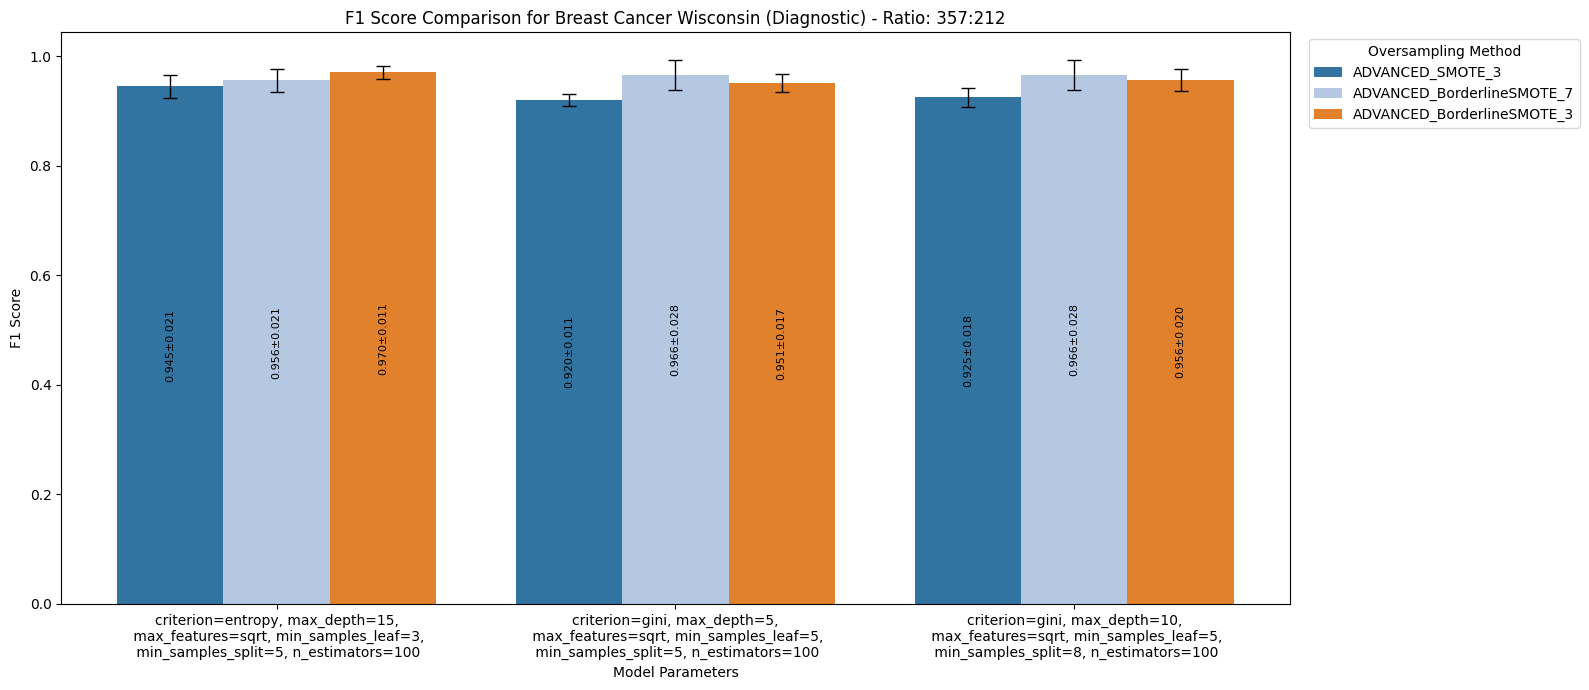

<Figure size 640x480 with 0 Axes>

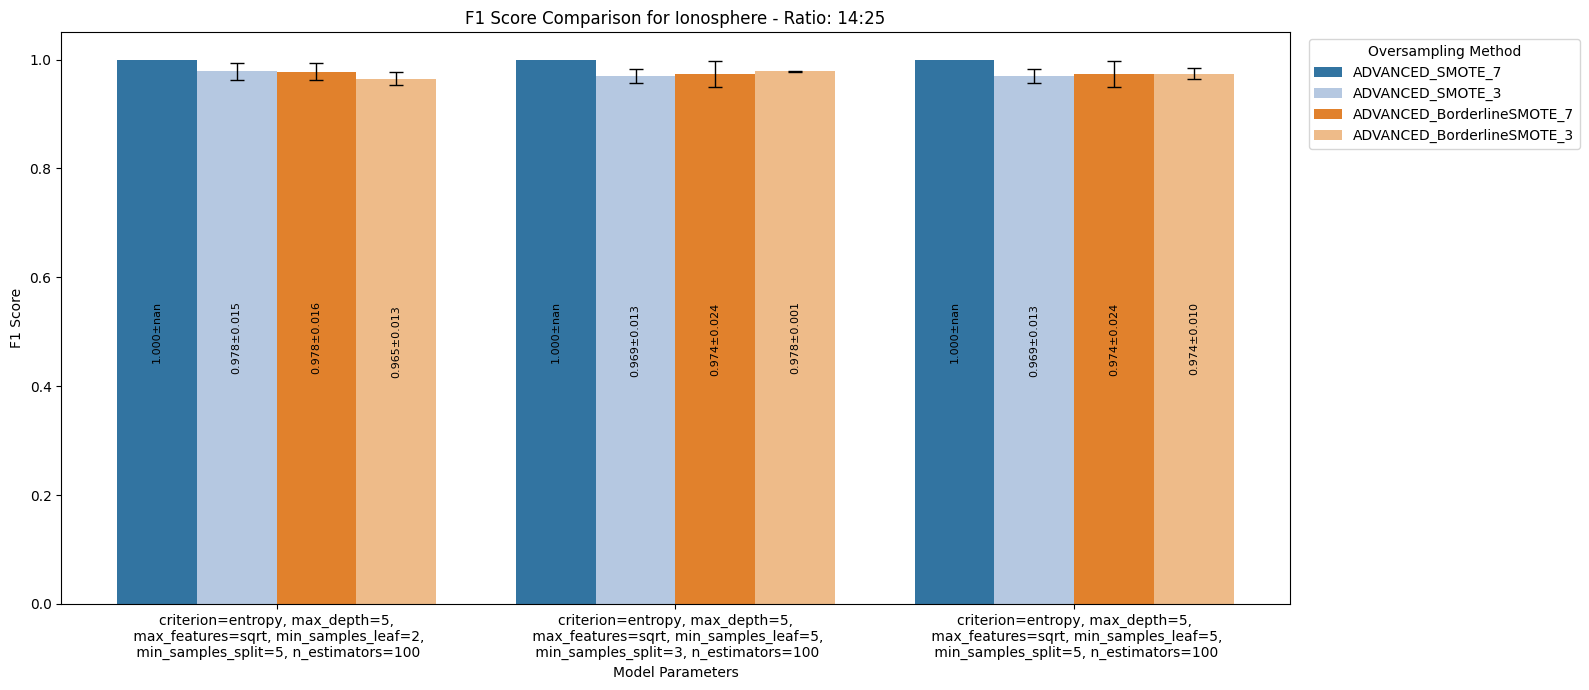

<Figure size 640x480 with 0 Axes>

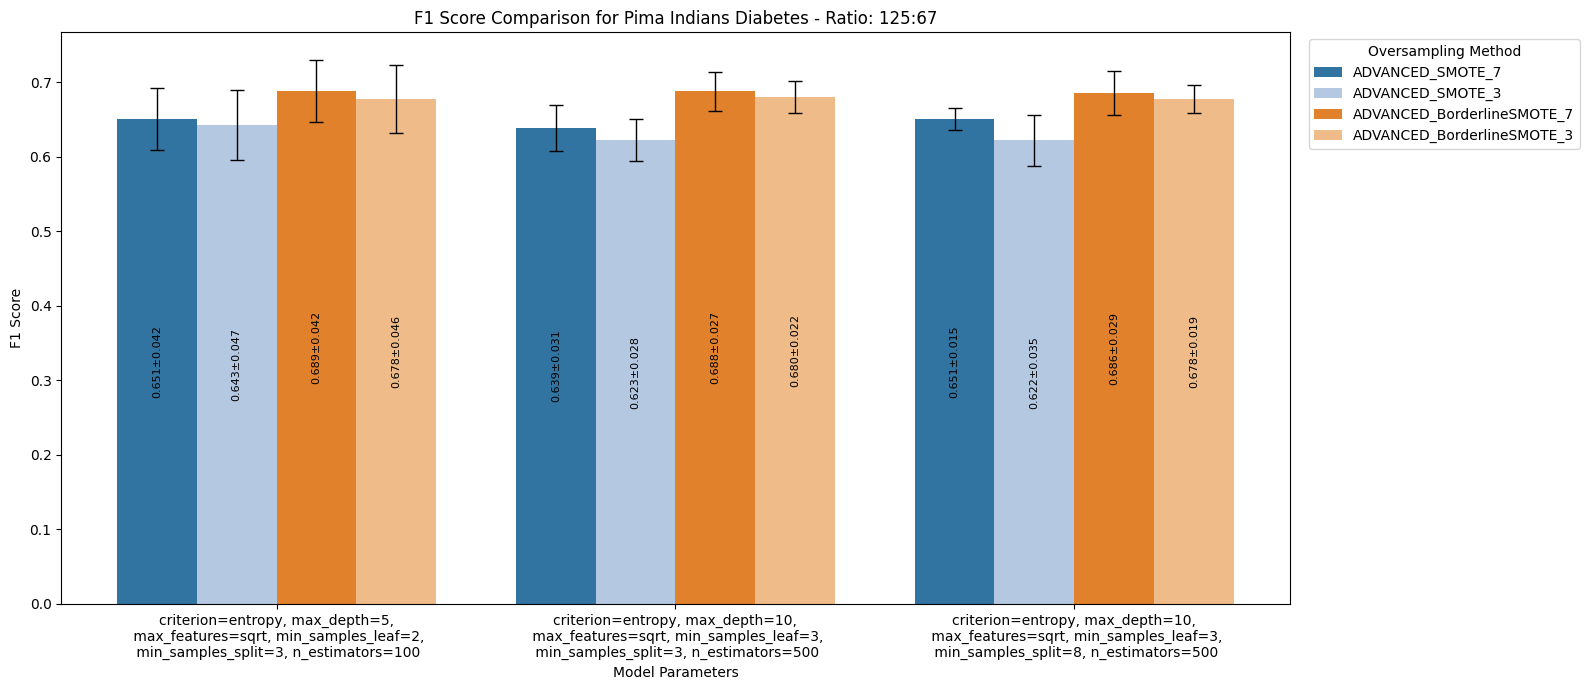

<Figure size 640x480 with 0 Axes>

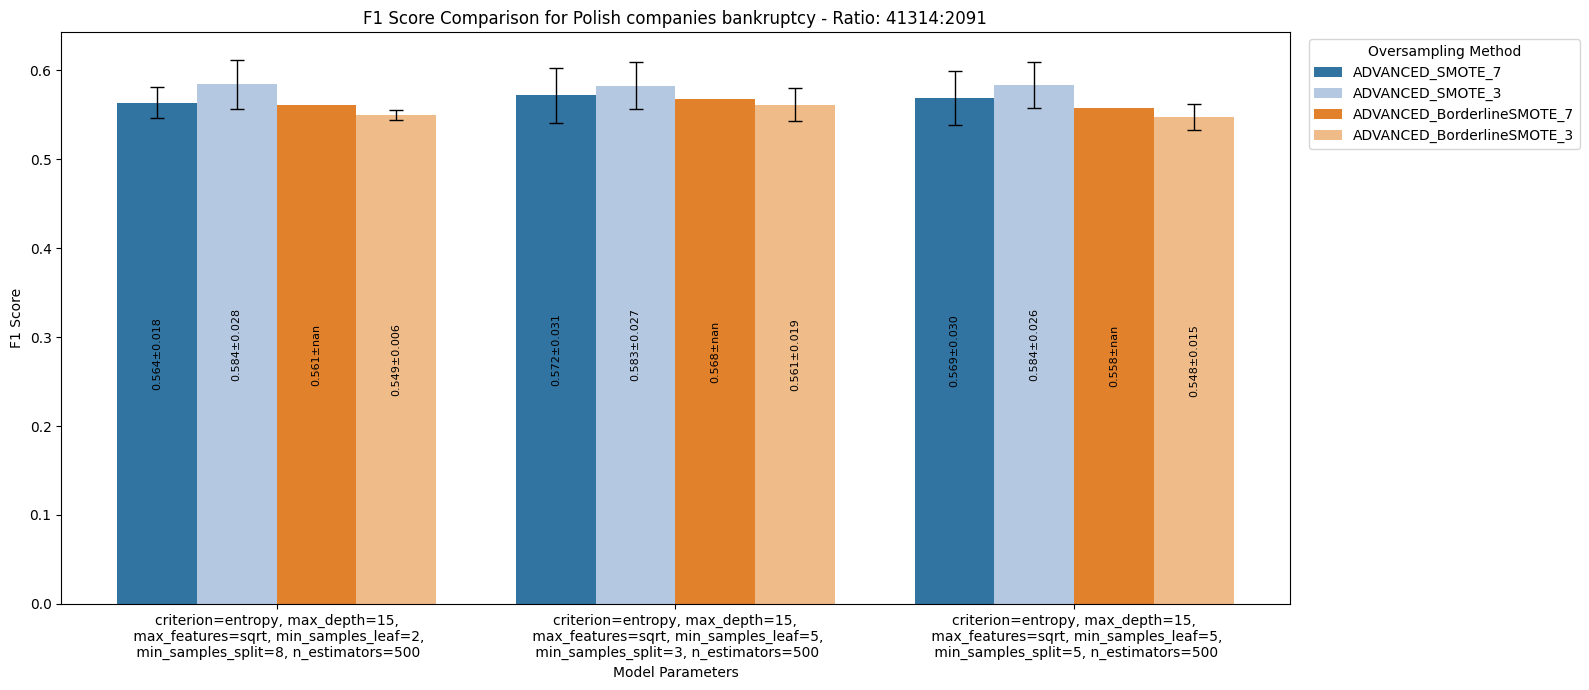

<Figure size 640x480 with 0 Axes>

In [ ]:
for dataset in datasets_additional:
    df = additional_advanced[additional_advanced["dataset_name"] == dataset]
    best_params = df.sort_values("mean", ascending=False)["params"].head(3).to_numpy()
    df = df[df["params"].isin(best_params)]
    
    ratio = dataset_info[dataset_info["dataset"] == dataset]["ratio (0 : 1)"].values[0]

    df.sort_values("oversampling_method", inplace=True, ascending=False)

    figure, ax = plt.subplots(figsize=(16, 7))
    palette = sns.color_palette("tab20", n_colors=df["oversampling_method"].nunique())
    sns.barplot(
        data=df,
        x="params",
        y="mean",
        hue="oversampling_method",
        ax=ax,
        palette=palette,
        capsize=0.1,
        ci=None,
    )

    for i, (param, group) in enumerate(df.groupby("params", sort=False)):
        for j, (method, row) in enumerate(group.iterrows()):
            x_pos = i + (j - (len(group) - 1) / 2) * 0.8 / len(group)
            ax.errorbar(
                x=x_pos,
                y=row["mean"],
                yerr=row["std"],
                fmt='none',
                ecolor='black',
                capsize=5,
                elinewidth=1,
            )
            
            if row["std"] > row["mean"] / 3:
                x_pos -= 0.01
            
            ax.text(
                x=x_pos,
                y=row["mean"]/2,
                s=f'{row["mean"]:.3f}±{row["std"]:.3f}',
                ha='center',
                va='center',
                fontsize=8,
                rotation=90
            )
    ax.set_title(f"F1 Score Comparison for {dataset} - Ratio: {ratio}")
    ax.set_xlabel("Model Parameters")
    ax.set_ylabel("F1 Score")
    ax.set_xticklabels(ax.get_xticklabels(), wrap=True)
    ax.legend(title="Oversampling Method", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
    plt.savefig(f"plots/additional_f1_score_comparison_{dataset}.png")    

In [ ]:
additional_advanced_mean = additional_advanced.pivot(
    columns="oversampling_method", index=["dataset_name", "params"], values="mean"
).reset_index()

additional_advanced_std = additional_advanced.pivot(
    columns="oversampling_method", index=["dataset_name", "params"], values="std"
).reset_index()

In [ ]:
additional_advanced.to_csv("tables/additional_advanced.csv", index=False)
additional_advanced_mean.to_csv("tables/additional_advanced_mean.csv", index=False)
additional_advanced_std.to_csv("tables/additional_advanced_std.csv", index=False)

In [ ]:
additional_advanced_mean.head()

oversampling_method,dataset_name,params,ADVANCED_BorderlineSMOTE_3,ADVANCED_BorderlineSMOTE_7,ADVANCED_SMOTE_3,ADVANCED_SMOTE_7
0,Breast Cancer Wisconsin (Diagnostic),"criterion=entropy, max_depth=10,\n max_feature...",0.955610,0.965366,0.923563,NaN
1,Breast Cancer Wisconsin (Diagnostic),"criterion=entropy, max_depth=10,\n max_feature...",0.960732,0.960732,0.923544,NaN
2,Breast Cancer Wisconsin (Diagnostic),"criterion=entropy, max_depth=10,\n max_feature...",0.960244,0.965366,0.925091,NaN
3,Breast Cancer Wisconsin (Diagnostic),"criterion=entropy, max_depth=10,\n max_feature...",0.960732,0.955610,0.923544,NaN
4,Breast Cancer Wisconsin (Diagnostic),"criterion=entropy, max_depth=10,\n max_feature...",0.960732,0.965366,0.924597,NaN


In [ ]:
additional_advanced_std

oversampling_method,dataset_name,params,ADVANCED_BorderlineSMOTE_3,ADVANCED_BorderlineSMOTE_7,ADVANCED_SMOTE_3,ADVANCED_SMOTE_7
0,Breast Cancer Wisconsin (Diagnostic),"criterion=entropy, max_depth=10,\n max_feature...",0.020562,0.014027,0.026383,NaN
1,Breast Cancer Wisconsin (Diagnostic),"criterion=entropy, max_depth=10,\n max_feature...",0.021958,0.021958,0.019628,NaN
2,Breast Cancer Wisconsin (Diagnostic),"criterion=entropy, max_depth=10,\n max_feature...",0.014027,0.014027,0.031967,NaN
3,Breast Cancer Wisconsin (Diagnostic),"criterion=entropy, max_depth=10,\n max_feature...",0.021958,0.020562,0.019628,NaN
4,Breast Cancer Wisconsin (Diagnostic),"criterion=entropy, max_depth=10,\n max_feature...",0.021958,0.014027,0.017748,NaN
...,...,...,...,...,...,...
427,Polish companies bankruptcy,"criterion=gini, max_depth=5,\n max_features=sq...",0.035582,NaN,0.036808,0.041205
428,Polish companies bankruptcy,"criterion=gini, max_depth=5,\n max_features=sq...",0.036465,NaN,0.036032,0.041989
429,Polish companies bankruptcy,"criterion=gini, max_depth=5,\n max_features=sq...",0.031823,NaN,0.037187,0.039703
430,Polish companies bankruptcy,"criterion=gini, max_depth=5,\n max_features=sq...",0.029855,NaN,0.037603,0.039733
